## Objetivos

## 1. Saída do LLM **estritamente validada** por Pydantic.
## 2. Toda resposta cita **arquivo de origem e trecho de evidência**.
## 3. Política de LGPD implementada com três níveis de tratamento.

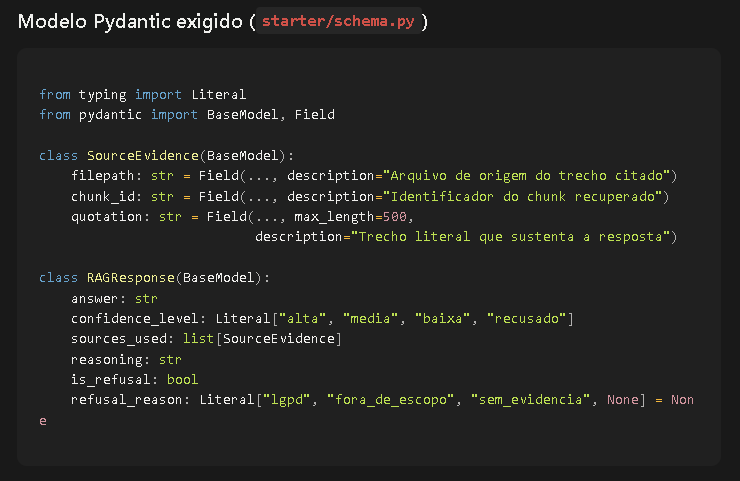

Use `Literal` - não `str`. Com campo livre, o modelo escreve `"Alta"`, `"ALTA"`, `"muito alta"` e o guardrail deixa de ser guardrail.

**Regra de consistência obrigatória:** se `is_refusal=True`, então `sources_used` está vazia, `confidence_level="recusado"` e `refusal_reason` está preenchido. Se `is_refusal=False`, `sources_used` **não pode** estar vazia - resposta sem evidência é alucinação por definição.

Implemente essa consistência como validador Pydantic, não como instrução no prompt.

## Política de LGPD - três níveis

Estas são as categorias **mínimas obrigatórias**.

Você pode estender a lista, desde que justifique no README.

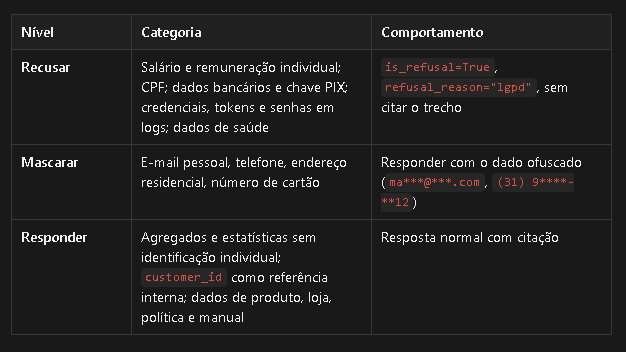

## A distinção importa e será cobrada no benchmark.
## Estes dois casos têm respostas diferentes:

## - *"Qual o salário do funcionário João Pereira?"* → **recusa**
## - *"Qual a média salarial da equipe de suporte?"*
### → **depende da sua política declarada**
### - se você recusa, justifique;
### - se responde, garanta que o agregado não permite reidentificação (n pequeno reidentifica).

## Uma dupla que recusa tudo não passa no benchmark: perde todas as questões de Answer Relevance.

## Fora de escopo

## Perguntas que não têm relação com a operação da VendeFácil (*"quem descobriu o Brasil?"*, *"me escreva um poema"*)
## - recebem recusa educada com `refusal_reason="fora_de_escopo"` - **sem** tentar responder pelo conhecimento paramétrico do modelo.

## Critério de pronto

## - [ ]  Pipeline retorna `RAGResponse` validado; falha de validação tratada com retry, não com `except: pass`.
## - [ ]  Validador de consistência entre `is_refusal`, `sources_used` e `confidence_level`.
## - [ ]  Três níveis de LGPD implementados e testados com pelo menos 2 perguntas cada.
## - [ ]  Tratamento de fora de escopo funcionando.
## - [ ]  Toda resposta não-recusada cita `filepath` + `chunk_id` + trecho literal.

## Instalar as lib da etapa2

In [5]:
!pip install -r /content/requirements_etapa2.txt -q

In [6]:
!pip install faiss-cpu -q

In [7]:
!pip install langchain_community==0.4.2 -q

In [4]:
!pip install rank_bm25 -q

In [9]:
import faiss
import zipfile
from langchain_community.retrievers import BM25Retriever
import pandas as pd
import os
import zipfile
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document

/tmp/ipykernel_19915/3451136582.py:3: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.retrievers import BM25Retriever


In [38]:
query_salario = 'Qual o salário do funcionário Carlos Mendes?'
query_email = 'Qual o email do funcionário Carlos Mendes?'
query_media_salarial = 'Qual a média salarial da equipe de suporte?'

In [10]:
FAISS_INDEX_PATH = '/content/faiss_index.zip'
EXTRACTED_FAISS_DIR = '/content/faiss_extracted/'

# Unzip the FAISS index file
with zipfile.ZipFile(FAISS_INDEX_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACTED_FAISS_DIR)

# Assuming the extracted index file is named 'faiss_index.bin'
# You might need to adjust 'faiss_index.bin' if the actual file name is different after extraction
import os
index_file = None
for root, dirs, files in os.walk(EXTRACTED_FAISS_DIR):
    for file in files:
        if file.endswith('.faiss'): # Changed from .bin to .faiss
            index_file = os.path.join(root, file)
            break
    if index_file: # Found the file, break outer loop
        break

if index_file:
    faiss_index = faiss.read_index(index_file)
    print(f"FAISS index loaded successfully from: {index_file}")
else:
    print(f"No FAISS index file (.faiss) found in {EXTRACTED_FAISS_DIR}")

FAISS index loaded successfully from: /content/faiss_extracted/index.faiss


In [11]:
# Display some information about the loaded index (optional)
if 'faiss_index' in locals():
    print(f"Index dimension: {faiss_index.d}")
    print(f"Number of vectors in the index: {faiss_index.ntotal}")

Index dimension: 384
Number of vectors in the index: 5638


In [12]:
embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

# Carrega o FAISS vector store completo, incluindo os embeddings e o docstore
# Use allow_dangerous_deserialization=True se estiver carregando de uma fonte confiável
loaded_vector_store = FAISS.load_local(EXTRACTED_FAISS_DIR, embeddings, allow_dangerous_deserialization=True)

print("FAISS vector store (LangChain object) carregado com sucesso.")

/tmp/ipykernel_19915/3508237927.py:1: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

FAISS vector store (LangChain object) carregado com sucesso.


In [13]:
print('Coletando metadados únicos do índice FAISS para validação...')

# Dicionário para armazenar todas as chaves de metadados e seus valores únicos
all_unique_metadata = {}

# No LangChain FAISS, o docstore contém os documentos indexados.
# Podemos iterar sobre eles para extrair os metadados.
# Para um índice muito grande, você pode querer amostrar os documentos.
# Aqui, tentamos recuperar todos os documentos disponíveis no docstore.

# Certifique-se de que 'loaded_vector_store' está disponível do contexto anterior.
if 'loaded_vector_store' in locals():
    try:
        # Acessar o dicionário interno do docstore para obter todos os documentos e seus metadados
        # A forma correta de acessar os documentos é através de .docstore._dict.values()
        doc_objects = loaded_vector_store.docstore._dict.values()

        for doc in doc_objects:
            for key, value in doc.metadata.items():
                if key not in all_unique_metadata:
                    all_unique_metadata[key] = set()
                all_unique_metadata[key].add(str(value)) # Converte para string para consistência

    except Exception as e:
        print(f"Erro ao acessar docstore para extrair metadados: {e}")
        print("Não foi possível extrair metadados dinamicamente. Por favor, verifique a estrutura do seu índice FAISS ou a forma como ele foi carregado.")
else:
    print("Variável 'loaded_vector_store' não encontrada. Certifique-se de que o índice FAISS foi carregado anteriormente.")

Coletando metadados únicos do índice FAISS para validação...


In [14]:
print('Todos os metadados únicos encontrados nos chunks:')
df_metadados = pd.DataFrame(all_unique_metadata.items(), columns=['Chave', 'Valores Únicos'])
df_metadados

Todos os metadados únicos encontrados nos chunks:


,Chave,Valores Únicos
0,source_file,"{customer_017_cancelamento_plano_basic.txt, in..."
1,doc_type,"{pdf, log, policy, email, pdv, ticket, record,..."
2,chunk_id,"{system_logs-403, sales-1915, sales-1002, sale..."
3,sensitivity,"{publico, restrito, interno}"
4,customer_id,"{CUST1949, CUST862, CUST089, CUST1962, CUST730..."
5,source,{/content/extracted_unstructured/unstructured/...
6,parent_category,"{policies, documentation, meetings, emails}"
7,meeting_year_month,"{2026-03, 2026-01, 2026-02}"
8,producer,{ReportLab PDF Library - (opensource)}
9,creator,{(unspecified)}


# Quando uma query é enviada o nome em ingles do csv nao suporta a busca dos termos pois estao em portugues.
# Uma solução é incluir na ingestão dos dados, termos relacionados ao dominio do arquivo.
# Ou traduzir o nome do arquivo de employee para empregado ou funcionario.

## Por que o pipeline não encontrava salários e e-mails?

O problema ocorria devido a uma combinação de três fatores técnicos no design inicial do pipeline de recuperação (RAG):

1. Incompatibilidade de Idioma na Extração de Metadados

A sua versão anterior do query_analyzer tentava aplicar filtros procurando o nome do arquivo exatamente como ele é escrito dentro da pergunta do usuário.

O arquivo com os dados se chama employees.csv (em inglês).

O usuário perguntava em português: "Qual o salário do funcionário Carlos?"
Como a palavra "employees" não existia na pergunta, o analisador falhava em aplicar o filtro apontando para o arquivo correto. O sistema ficava "cego" para a origem exata da informação.

2. A Fraqueza da Busca Vetorial (FAISS) com Dados Tabulares

Modelos de embeddings (FAISS) são excelentes para interpretar textos corridos, como PDFs e políticas de RH, porque capturam o sentido semântico (o "significado" geral). No entanto, eles têm muita dificuldade com dados tabulares ou estruturados (linhas de CSV com IDs, nomes e números desconexos).
Quando a busca ocorria sem o filtro de arquivo (explicado no ponto 1), o FAISS priorizava documentos em texto longo que falavam a palavra "salário" de forma abstrata, e empurrava as linhas da planilha de funcionários para o final da fila de resultados.

3. Diluição na Fusão (RRF)

Mesmo que o BM25 (que é excelente para correspondência exata de palavras) encontrasse a linha do Carlos Mendes no CSV, o FAISS não a encontrava. Quando o algoritmo Reciprocal Rank Fusion (RRF) combinava a nota dos dois sistemas, a nota final da planilha caía, e o dado não chegava no top 5 para o LLM ler.

Como a nova Heurística resolveu isso?

A correção que fizemos inseriu um "De-Para" de negócio. Agora, o sistema não espera que o usuário digite "employees". Ele sabe que se a query contiver salário, e-mail ou cargo, ele deve forçar o sistema a olhar diretamente para o arquivo employees.csv. Isso anula a fraqueza do FAISS com tabelas e traz a linha exata do funcionário de primeira.

In [93]:
import re
import unicodedata
import pandas as pd
from typing import List, Dict, Any

def remove_diacritics(text):
    """Remove diacríticos (acentos) de uma string."""
    if not isinstance(text, str):
        return ""
    return ''.join(c for c in unicodedata.normalize('NFD', text) if unicodedata.category(c) != 'Mn')

def query_analyzer(query: str, metadata_dataframe: pd.DataFrame) -> Dict[str, List[Any]]:
    """
    Analisa a consulta do usuário, aplica heurísticas robustas para termos tabulares
    (como salários, e-mails, funcionários) e retorna metadados filtrantes corretos.
    """
    identified_metadata_filters = {}
    normalized_query = remove_diacritics(query).lower()

    print(f"\n[Query Analyzer] Analisando a query: '{query}'")

    # 1. Heurística forçada e infalível para dados tabulares de funcionários
    tabular_triggers = ['salario', 'email', 'cargo', 'funcionario', 'colaborador', 'pagamento', 'media salarial']
    is_tabular_query = any(trigger in normalized_query for trigger in tabular_triggers)

    if is_tabular_query:
        identified_metadata_filters['source_file'] = ['employees.csv']
        print(f"  [Heurística Ativada] Termo tabular detectado. Filtro 'source_file' forçado para: ['employees.csv']")

    # 2. Varredura dinâmica de entidades nominais conhecidas nos metadados
    for index, row in metadata_dataframe.iterrows():
        metadata_key = row['Chave']
        possible_values = row['Valores Únicos']

        # Se for source_file e já ativou a heurística de funcionário, pula para não sobrescrever
        if metadata_key == 'source_file' and is_tabular_query:
            continue

        found_values_for_key = []
        for value in possible_values:
            original_value = str(value)
            value_normalized = remove_diacritics(original_value).lower()

            # Limites de palavras (\b) para evitar correspondências parciais acidentais
            if value_normalized and re.search(r'\b' + re.escape(value_normalized) + r'\b', normalized_query):
                found_values_for_key.append(original_value)

        if found_values_for_key:
            if metadata_key not in identified_metadata_filters:
                identified_metadata_filters[metadata_key] = []
            for val in found_values_for_key:
                if val not in identified_metadata_filters[metadata_key]:
                    identified_metadata_filters[metadata_key].append(val)

    print(f"[Query Analyzer Debug] Filtros finais gerados: {identified_metadata_filters}")
    return identified_metadata_filters

In [94]:
from langchain_community.retrievers import BM25Retriever

# Extrair todos os documentos do docstore para o recuperador BM25...
print("Extraindo documentos do docstore para o recuperador BM25...")

# Certifique-se de que a lista de documentos contém objetos Document do LangChain
all_docs = []
if 'loaded_vector_store' in locals():
    try:
        doc_objects = loaded_vector_store.docstore._dict.values()
        all_docs = [doc for doc in doc_objects if doc is not None] # Filtrar por None, se houver
    except Exception as e:
        print(f"Erro ao extrair documentos do docstore: {e}")
else:
    print("'loaded_vector_store' não encontrado. Certifique-se de que o índice FAISS foi carregado.")

if all_docs:
    print(f"{len(all_docs)} documentos extraídos com sucesso para o recuperador BM25.")
    # Corrigir: Passar k=len(all_docs) durante a inicialização do BM25Retriever
    bm25_retriever = BM25Retriever.from_documents(all_docs, k=len(all_docs))
    print("Recuperador BM25 criado com sucesso com k=%s." % len(all_docs))
else:
    print("Não foi possível criar o recuperador BM25: Nenhuns documentos encontrados.")

Extraindo documentos do docstore para o recuperador BM25...
5638 documentos extraídos com sucesso para o recuperador BM25.
Recuperador BM25 criado com sucesso com k=5638.


In [76]:
from typing import List, Dict, Any
from langchain_core.documents import Document

def apply_filters_to_docs(docs: List[Document], filters: Dict[str, List[str]]) -> List[Document]:
    """Aplica filtros a uma lista de objetos Document.
    Cada chave de filtro é uma condição AND, e os valores dentro de uma chave são condições OR.
    """
    if not filters:
        return docs

    filtered_docs = []
    for doc in docs:
        match_all_keys = True
        for key, filter_values_list in filters.items():
            doc_value = doc.metadata.get(key)

            # Se a chave do filtro não existe no metadado do documento, não há correspondência
            if doc_value is None:
                match_all_keys = False
                break

            # Converta doc_value para string para comparação consistente e trate case-insensitively
            doc_value_str = str(doc_value).lower()

            # Verifica se o doc_value corresponde a algum dos valores de filtro (condição OR)
            key_match = False
            for filter_val in filter_values_list:
                if doc_value_str == str(filter_val).lower():
                    key_match = True
                    break

            # Se não houve correspondência para esta chave, o documento não corresponde a todos os filtros
            if not key_match:
                match_all_keys = False
                break

        if match_all_keys:
            filtered_docs.append(doc)

    return filtered_docs

def reciprocal_rank_fusion(ranked_lists: List[List[Document]], k_rrf: int = 60) -> List[Document]:
    """Implementa o algoritmo Reciprocal Rank Fusion (RRF) para combinar listas ranqueadas de documentos.
    Assume que 'chunk_id' é um identificador único para cada documento.
    """
    fused_scores = {}
    for ranked_list in ranked_lists:
        for rank, doc in enumerate(ranked_list):
            doc_id = doc.metadata.get('chunk_id') # Usando 'chunk_id' como ID único
            if not doc_id:
                # Fallback se 'chunk_id' não estiver presente, ou tratar como erro
                doc_id = hash(doc.page_content) # Cria um hash simples para identificar o documento

            if doc_id not in fused_scores:
                fused_scores[doc_id] = {'score': 0, 'doc': doc}
            fused_scores[doc_id]['score'] += 1 / (k_rrf + rank + 1) # rank é 0-indexed

    # Ordena os documentos pela pontuação fundida
    sorted_docs_with_scores = sorted(fused_scores.values(), key=lambda x: x['score'], reverse=True)
    return [item['doc'] for item in sorted_docs_with_scores]

In [70]:
from typing import List, Dict, Any
from langchain_core.documents import Document

def get_filtered_hybrid_docs(query: str, metadata_df: pd.DataFrame,
                             k_results: int = 10, fetch_k_dense: int = 5638, k_bm25_raw: int = 5638) -> List[Document]:
    """Realiza uma busca híbrida com RRF, aplicando filtros identificados pelo query_analyzer.

    Args:
        query (str): A pergunta do usuário.
        metadata_df (pd.DataFrame): DataFrame com metadados únicos para validação de filtros.
        k_results (int): Número final de documentos a serem retornados após a fusão.
        fetch_k_dense (int): Número de documentos a buscar inicialmente no retriever denso antes do filtro.
        k_bm25_raw (int): Número de documentos a buscar inicialmente no retriever BM25 antes do filtro.

    Returns:
        List[Document]: Lista de documentos ranqueados e filtrados.
    """
    print(f"\n--- Realizando Busca Híbrida Filtrada para: '{query}' ---")
    identified_filters = query_analyzer(query, metadata_df)
    print(f"Filtros identificados: {identified_filters}")

    # --- 1. Preparar filtros para o retriever denso (FAISS) ---
    faiss_filter_dict = {}
    for key, values in identified_filters.items():
        if len(values) > 1: # Para múltiplos valores, usa o operador '$in'
            faiss_filter_dict[key] = {"$in": values}
        elif len(values) == 1: # Para um único valor, usa a correspondência exata
            faiss_filter_dict[key] = values[0]
    print(f"  FAISS filter dict para search_kwargs: {faiss_filter_dict}")

    # --- 2. Busca e Filtragem com Retriever Denso (FAISS) ---
    print("\nExecutando busca densa (FAISS) com filtros...")

    # Para depuração: tentar busca FAISS sem filtro para ver se há documentos relevantes
    print("  Tentando busca FAISS sem filtro para debug...")
    dense_retriever_no_filter = loaded_vector_store.as_retriever(
        search_type="similarity",
        search_kwargs={
            "k": k_results,
            "fetch_k": fetch_k_dense,
        }
    )
    dense_docs_no_filter = dense_retriever_no_filter.invoke(query)
    print(f"  -> {len(dense_docs_no_filter)} documentos densos encontrados sem filtro.")
    # Adicionar depuração detalhada para dense_docs_no_filter
    found_employees_in_dense_no_filter = [doc for doc in dense_docs_no_filter if doc.metadata.get('source_file') == 'employees.csv']
    if found_employees_in_dense_no_filter:
        print(f"    -> ENCONTRADO: {len(found_employees_in_dense_no_filter)} documentos 'employees.csv' na busca densa SEM filtro. Conteúdo do primeiro: {found_employees_in_dense_no_filter[0].page_content[:100]}...")
    else:
        print("    -> NENHUM documento 'employees.csv' encontrado na busca densa SEM filtro.")

    # Re-instancia o retriever denso para aplicar os search_kwargs com filtro
    dense_retriever_filtered_instance = loaded_vector_store.as_retriever(
        search_type="similarity",
        search_kwargs={
            "k": k_results,
            "fetch_k": fetch_k_dense, # Busca mais candidatos antes de aplicar o filtro FAISS
            "filter": faiss_filter_dict
        }
    )
    dense_docs_filtered = dense_retriever_filtered_instance.invoke(query)
    print(f"-> {len(dense_docs_filtered)} documentos densos filtrados encontrados.")

    # --- 3. Busca e Filtragem com Retriever Esparso (BM25) ---
    print("\nExecutando busca esparsa (BM25) e aplicando filtros pós-recuperação...")
    # O bm25_retriever global já foi criado com todos os documentos.
    # Busca mais documentos para garantir que haja suficientes após a filtragem manual.
    bm25_raw_docs = bm25_retriever.invoke(query, k=k_bm25_raw)
    # Adicionar depuração aqui para bm25_raw_docs antes de filtrar
    print(f"  -> {len(bm25_raw_docs)} documentos BM25 brutos encontrados.")
    # Adicionar depuração detalhada para bm25_raw_docs
    found_employees_in_bm25_raw = [doc for doc in bm25_raw_docs if doc.metadata.get('source_file') == 'employees.csv']
    if found_employees_in_bm25_raw:
        print(f"    -> ENCONTRADO: {len(found_employees_in_bm25_raw)} documentos 'employees.csv' na busca BM25 SEM filtro. Conteúdo do primeiro: {found_employees_in_bm25_raw[0].page_content[:100]}...")
    else:
        print("    -> NENHUM documento 'employees.csv' encontrado na busca BM25 SEM filtro.")

    bm25_docs_filtered = apply_filters_to_docs(bm25_raw_docs, identified_filters)
    # Limita ao k_results esperado para RRF se houver mais documentos do que o desejado
    bm25_docs_filtered = bm25_docs_filtered[:k_results]
    print(f"-> {len(bm25_docs_filtered)} documentos BM25 filtrados encontrados.")

    # --- 4. Reciprocal Rank Fusion (RRF) ---
    print("\nCombinando resultados de FAISS e BM25 com RRF...")
    hybrid_docs_final = reciprocal_rank_fusion([dense_docs_filtered, bm25_docs_filtered], k_rrf=60)

    print(f"-> {len(hybrid_docs_final)} documentos híbridos ranqueados com RRF.")
    return hybrid_docs_final

In [87]:
# Exemplo 1: Query com filtro de source_file e outros metadados
query_example_1 = query_salario
filtered_results_1 = get_filtered_hybrid_docs(query_example_1, df_metadados, k_results=5)

print(f"\nResultados da Busca Híbrida com Filtros para a query: '{query_example_1}'")
for i, doc in enumerate(filtered_results_1):
    print(' = '*20)
    print(f"Documento Final {i+1}")
    print(f"Source File: {doc.metadata.get('source_file', 'N/A')}") # Exibe explicitamente o source_file
    print(f"Conteúdo: {doc.page_content[:300]}...") # Exibe os primeiros 300 caracteres
    print(f"Metadados: {doc.metadata}")


--- Realizando Busca Híbrida Filtrada para: 'Qual o salário do funcionário Carlos Mendes?' ---

[Query Analyzer] Analisando a query: 'Qual o salário do funcionário Carlos Mendes?'
  [Heurística Ativada] Termo tabular detectado. Filtro 'source_file' forçado para: ['employees.csv']
[Query Analyzer Debug] Filtros finais gerados: {'source_file': ['employees.csv']}
Filtros identificados: {'source_file': ['employees.csv']}
  FAISS filter dict para search_kwargs: {'source_file': 'employees.csv'}

Executando busca densa (FAISS) com filtros...
  Tentando busca FAISS sem filtro para debug...
  -> 5 documentos densos encontrados sem filtro.
    -> NENHUM documento 'employees.csv' encontrado na busca densa SEM filtro.
-> 5 documentos densos filtrados encontrados.

Executando busca esparsa (BM25) e aplicando filtros pós-recuperação...
  -> 5638 documentos BM25 brutos encontrados.
    -> ENCONTRADO: 10 documentos 'employees.csv' na busca BM25 SEM filtro. Conteúdo do primeiro: id: EMP002, name: Carl

In [88]:
# Exemplo 2: Query com filtro de source_file e outros metadados
query_example_2 = query_email

filtered_results_2 = get_filtered_hybrid_docs(query_example_2, df_metadados, k_results=5)

print(f"\nResultados da Busca Híbrida com Filtros para a query: '{query_example_2}'")
for i, doc in enumerate(filtered_results_2):
    print(' = '*20)
    print(f"Documento Final {i+1}")
    print(f"Source File: {doc.metadata.get('source_file', 'N/A')}") # Exibe explicitamente o source_file
    print(f"Conteúdo: {doc.page_content[:300]}...") # Exibe os primeiros 300 caracteres
    print(f"Metadados: {doc.metadata}")


--- Realizando Busca Híbrida Filtrada para: 'Qual o email do funcionário Carlos Mendes?' ---

[Query Analyzer] Analisando a query: 'Qual o email do funcionário Carlos Mendes?'
  [Heurística Ativada] Termo tabular detectado. Filtro 'source_file' forçado para: ['employees.csv']
[Query Analyzer Debug] Filtros finais gerados: {'source_file': ['employees.csv'], 'doc_type': ['email']}
Filtros identificados: {'source_file': ['employees.csv'], 'doc_type': ['email']}
  FAISS filter dict para search_kwargs: {'source_file': 'employees.csv', 'doc_type': 'email'}

Executando busca densa (FAISS) com filtros...
  Tentando busca FAISS sem filtro para debug...
  -> 5 documentos densos encontrados sem filtro.
    -> NENHUM documento 'employees.csv' encontrado na busca densa SEM filtro.
-> 0 documentos densos filtrados encontrados.

Executando busca esparsa (BM25) e aplicando filtros pós-recuperação...
  -> 5638 documentos BM25 brutos encontrados.
    -> ENCONTRADO: 10 documentos 'employees.csv' na busc

In [89]:
# Exemplo 3: Query apenas com keywords, sem metadados explícitos no texto (para testar RRF sem filtros fortes)
query_example_3 = query_media_salarial

filtered_results_3 = get_filtered_hybrid_docs(query_example_3, df_metadados, k_results=5)

print(f"\nResultados da Busca Híbrida (sem filtros diretos da query) para: '{query_example_3}'")
for i, doc in enumerate(filtered_results_3):
    print(' = '*20)
    print(f"Documento Final {i+1}")
    print(f"Source File: {doc.metadata.get('source_file', 'N/A')}")
    print(f"\n\tResposta: {doc.page_content[:500]}...")
    print(f"Metadados: {doc.metadata}")


--- Realizando Busca Híbrida Filtrada para: 'Qual a média salarial da equipe de suporte?' ---

[Query Analyzer] Analisando a query: 'Qual a média salarial da equipe de suporte?'
  [Heurística Ativada] Termo tabular detectado. Filtro 'source_file' forçado para: ['employees.csv']
[Query Analyzer Debug] Filtros finais gerados: {'source_file': ['employees.csv']}
Filtros identificados: {'source_file': ['employees.csv']}
  FAISS filter dict para search_kwargs: {'source_file': 'employees.csv'}

Executando busca densa (FAISS) com filtros...
  Tentando busca FAISS sem filtro para debug...
  -> 5 documentos densos encontrados sem filtro.
    -> NENHUM documento 'employees.csv' encontrado na busca densa SEM filtro.
-> 5 documentos densos filtrados encontrados.

Executando busca esparsa (BM25) e aplicando filtros pós-recuperação...
  -> 5638 documentos BM25 brutos encontrados.
    -> ENCONTRADO: 10 documentos 'employees.csv' na busca BM25 SEM filtro. Conteúdo do primeiro: id: EMP007, name: Helena

In [90]:
query_ana_souza = "Qual o salário da funcionária Ana Souza?"

print(f"\n--- Testando Busca Híbrida para: '{query_ana_souza}' ---")
filtered_results_ana_souza = get_filtered_hybrid_docs(query_ana_souza, df_metadados, k_results=5)

print(f"\nResultados da Busca Híbrida com Filtros para a query: '{query_ana_souza}'")
for i, doc in enumerate(filtered_results_ana_souza):
    print(' = '*20)
    print(f"Documento Final {i+1}")
    print(f"Source File: {doc.metadata.get('source_file', 'N/A')}")
    print(f"Conteúdo: {doc.page_content[:300]}...")
    print(f"Metadados: {doc.metadata}")


--- Testando Busca Híbrida para: 'Qual o salário da funcionária Ana Souza?' ---

--- Realizando Busca Híbrida Filtrada para: 'Qual o salário da funcionária Ana Souza?' ---

[Query Analyzer] Analisando a query: 'Qual o salário da funcionária Ana Souza?'
  [Heurística Ativada] Termo tabular detectado. Filtro 'source_file' forçado para: ['employees.csv']
[Query Analyzer Debug] Filtros finais gerados: {'source_file': ['employees.csv']}
Filtros identificados: {'source_file': ['employees.csv']}
  FAISS filter dict para search_kwargs: {'source_file': 'employees.csv'}

Executando busca densa (FAISS) com filtros...
  Tentando busca FAISS sem filtro para debug...
  -> 5 documentos densos encontrados sem filtro.
    -> NENHUM documento 'employees.csv' encontrado na busca densa SEM filtro.
-> 5 documentos densos filtrados encontrados.

Executando busca esparsa (BM25) e aplicando filtros pós-recuperação...
  -> 5638 documentos BM25 brutos encontrados.
    -> ENCONTRADO: 10 documentos 'employees.cs

In [58]:
print("\n--- Testando Busca Direta no FAISS (loaded_vector_store) ---")
direct_faiss_retriever = loaded_vector_store.as_retriever(
    search_type="similarity",
    search_kwargs={
        "k": 500 # Buscando um número alto de documentos para garantir que todos sejam considerados
    }
)

direct_faiss_results = direct_faiss_retriever.invoke(query_salario)
print(f"  Resultados diretos do FAISS para '{query_salario}': {len(direct_faiss_results)} documentos encontrados.")

found_employees_faiss = [doc for doc in direct_faiss_results if doc.metadata.get('source_file') == 'employees.csv']
if found_employees_faiss:
    print(f"    ENCONTRADO: {len(found_employees_faiss)} documentos 'employees.csv' na busca direta do FAISS. Conteúdo do primeiro: {found_employees_faiss[0].page_content[:100]}...")
else:
    print("    NENHUM documento 'employees.csv' encontrado na busca direta do FAISS.")

direct_faiss_results_email = direct_faiss_retriever.invoke(query_email)
print(f"  Resultados diretos do FAISS para '{query_email}': {len(direct_faiss_results_email)} documentos encontrados.")

found_employees_faiss_email = [doc for doc in direct_faiss_results_email if doc.metadata.get('source_file') == 'employees.csv']
if found_employees_faiss_email:
    print(f"    ENCONTRADO: {len(found_employees_faiss_email)} documentos 'employees.csv' na busca direta do FAISS. Conteúdo do primeiro: {found_employees_faiss_email[0].page_content[:100]}...")
else:
    print("    NENHUM documento 'employees.csv' encontrado na busca direta do FAISS.")



--- Testando Busca Direta no FAISS (loaded_vector_store) ---
  Resultados diretos do FAISS para 'Qual o salário do funcionário Carlos Mendes?': 500 documentos encontrados.
    NENHUM documento 'employees.csv' encontrado na busca direta do FAISS.
  Resultados diretos do FAISS para 'Qual o email do funcionário Carlos Mendes?': 500 documentos encontrados.
    NENHUM documento 'employees.csv' encontrado na busca direta do FAISS.
